Importing Libraries

In [494]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import yfinance as yf
from scipy.stats import norm,t,expon,cauchy,laplace,logistic

Fetching the data

In [495]:
data= yf.download ("BHARTIARTL.NS",start='2024-01-01',end='2025-01-01',interval="1d")
data.columns= data.columns.droplevel(1)
data=data.reset_index()
data

/tmp/ipython-input-495-1508426608.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2024-01-01,1007.435730,1026.230951,1001.419271,1026.230951,3804406
1,2024-01-02,1016.037842,1019.766999,1010.369419,1011.761684,6865791
2,2024-01-03,1029.463013,1031.253086,1015.689792,1026.231024,3604276
3,2024-01-04,1042.092651,1052.932269,1021.855454,1029.512732,4664043
4,2024-01-05,1040.799805,1057.755364,1033.192176,1047.959976,4008221
...,...,...,...,...,...,...
241,2024-12-24,1583.900024,1598.800049,1575.000000,1590.000000,3610076
242,2024-12-26,1599.500000,1606.849976,1581.099976,1583.900024,3400479
243,2024-12-27,1599.849976,1628.449951,1596.300049,1599.500000,2559578
244,2024-12-30,1586.900024,1613.050049,1581.099976,1605.000000,4438130


Getting Log Returns

In [496]:
returns= np.log(data["Close"] / data["Close"].shift(1)).dropna()

Plotting the Histogram and KDE of returns

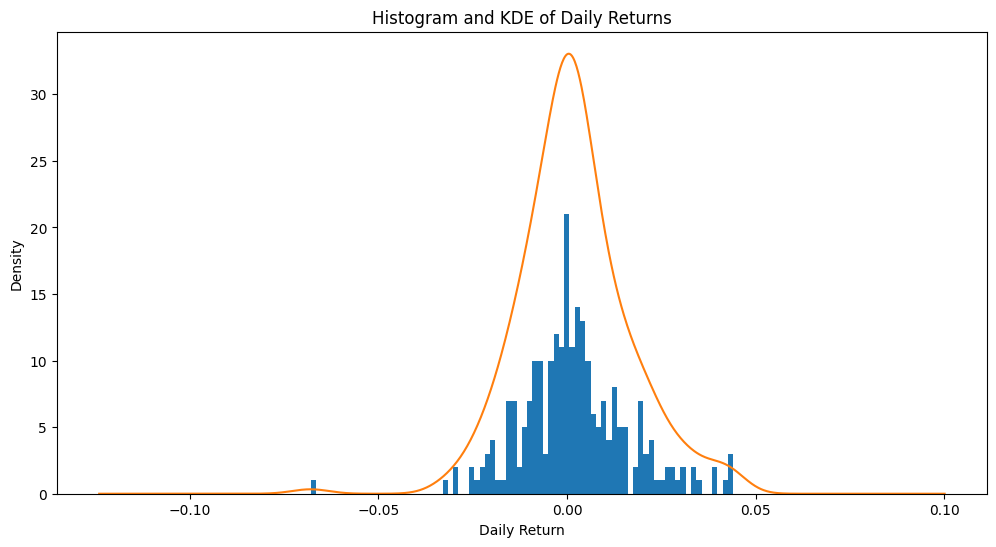

In [497]:
plt.figure(figsize=(12,6))
plt.hist(returns, bins=80)
returns.plot.kde()
plt.title('Histogram and KDE of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.show()

Normal Distribution and their parameters

In [498]:
loc_n,scale_n= norm.fit(returns)
xn= np.linspace(min(returns), max(returns), 500)
yn= norm.pdf(xn,loc_n,scale_n)
fig= go.Figure()
fig.add_trace(go.Scatter(x=xn, y=yn, line=dict(color='red', width=2)))
fig.update_layout(title=dict(text="NORMAL DISTRIBUTION",x=0.5,y=0.9,font=dict(size=30)), xaxis_title='returns', yaxis_title='density')
fig.show()
print("\nNormal Distribution (MLE):")
print("Location:",loc_n)
print("Scale:",scale_n)


Normal Distribution (MLE):
Location: 0.0018567742795088894
Scale: 0.014666963830637035


T Distribution and their parameters

In [499]:
dof,loc_t,scale_t= t.fit(returns)
xt= np.linspace(min(returns), max(returns), 500)
yt= t.pdf(xt,dof,loc_t,scale_t)
fig= go.Figure()
fig.add_trace(go.Scatter(x=xt, y=yt, line=dict(color='red', width=2)))
fig.update_layout(title=dict(text="T DISTRIBUTION",x=0.5,y=0.9,font=dict(size=30)), xaxis_title='returns', yaxis_title='density')
fig.show()
print("\nT Distribution (MLE):")
print("Degree of Freedom:",dof)
print("Location:",loc_t)
print("Scale:",scale_t)


T Distribution (MLE):
Degree of Freedom: 4.486293269631551
Location: 0.0011628190583319545
Scale: 0.011216994438423791


Logistic Distribution and their parameters

In [500]:
loc_lo,scale_lo= logistic.fit(returns)
xlo= np.linspace(min(returns), max(returns), 500)
ylo= cauchy.pdf(xlo,loc_lo,scale_lo)
fig= go.Figure()
fig.add_trace(go.Scatter(x=xlo, y=ylo, line=dict(color='red', width=2)))
fig.update_layout(title=dict(text="LOGISTIC DISTRIBUTION",x=0.5,y=0.9,font=dict(size=30)), xaxis_title='returns', yaxis_title='density')
fig.show()
print("\nLogistic Distribution (MLE):")
print("Location:",loc_lo)
print("Scale:",scale_lo)


Logistic Distribution (MLE):
Location: 0.0013521624305725787
Scale: 0.007856467457727308


Cauchy Distribution and their parameters

In [501]:
loc_c,scale_c= cauchy.fit(returns)
xc= np.linspace(min(returns), max(returns), 500)
yc= cauchy.pdf(xc,loc_c,scale_c)
fig= go.Figure()
fig.add_trace(go.Scatter(x=xc, y=yc, line=dict(color='red', width=2)))
fig.update_layout(title=dict(text="CAUCHY DISTRIBUTION",x=0.5,y=0.9,font=dict(size=30)), xaxis_title='returns', yaxis_title='density')
fig.show()
print("\nCauchy Distribution (MLE):")
print("Location:",loc_c)
print("Scale:",scale_c)


Cauchy Distribution (MLE):
Location: 0.0006000784626970852
Scale: 0.007074336431509499


Laplace Distribution and their parameters

In [502]:
loc_l,scale_l= laplace.fit(returns)
xl= np.linspace(min(returns), max(returns), 500)
yl= laplace.pdf(xl,loc_l,scale_l)
fig= go.Figure()
fig.add_trace(go.Scatter(x=xl, y=yl, line=dict(color='red', width=2)))
fig.update_layout(title=dict(text="LAPLACE DISTRIBUTION",x=0.5,y=0.9,font=dict(size=30)), xaxis_title='returns', yaxis_title='density')
fig.show()
print("\nLaplace Distribution (MLE):")
print("Location:",loc_l)
print("Scale:",scale_l)


Laplace Distribution (MLE):
Location: 0.0006340758915526927
Scale: 0.010648207974228465


Hypothesis Testing using KS test

In [503]:
def ks_test(distribution, parameters,name, m=1000):
    sorted= np.sort(returns)
    n= len(sorted)
    empirical_cdf= np.arange(1,n+1)/n
    theoretical_cdf= distribution.cdf(sorted,*parameters)
    D= np.max(np.abs(empirical_cdf - theoretical_cdf))
    Tn= np.sqrt(n)*D

    stats= []
    for _ in range(m):                                  ### 1000  simulations for comparing with Actual Tn(threshold) so as to find P_value
        sim_data= distribution.rvs(*parameters,size=n)
        sim_data_sorted= np.sort(sim_data)
        ecdf_sim= np.arange(1,n+1)/n
        tcdf_sim= distribution.cdf(sim_data_sorted,*parameters)
        D_sim= np.max(np.abs(ecdf_sim - tcdf_sim))
        Tn_sim= np.sqrt(n)*D_sim
        stats.append(Tn_sim)

    p_value= np.mean(np.array(stats)>=Tn)

    # print("Distribution:",name)   ### Testing
    # print("KS Statistic:",D)
    # print("p-value:",p_value)
    return {
        "Distribution": name,
        "KS Statistic": D,
        "p-value": p_value
    }

Just keeping the results of different distributions in a list

In [504]:
rank=[]
rank.append(ks_test(norm,(loc_n,scale_n),"Normal"))
rank.append(ks_test(t,(dof,loc_t,scale_t),"Student's T"))
rank.append(ks_test(logistic,(loc_lo,scale_lo),"Logistic"))
rank.append(ks_test(laplace,(loc_l,scale_l),"Laplace"))
rank.append(ks_test(cauchy,(loc_c,scale_c),"Cauchy"))

Ranking according to the p_value

In [505]:
df= pd.DataFrame(rank).sort_values("p-value",ascending=False)
df.reset_index(drop=True,inplace=True)
df

,Distribution,KS Statistic,p-value
0,Laplace,0.039310,0.776
1,Student's T,0.043804,0.675
2,Logistic,0.055729,0.360
3,Cauchy,0.063761,0.221
4,Normal,0.086736,0.050


Plotting the p_values

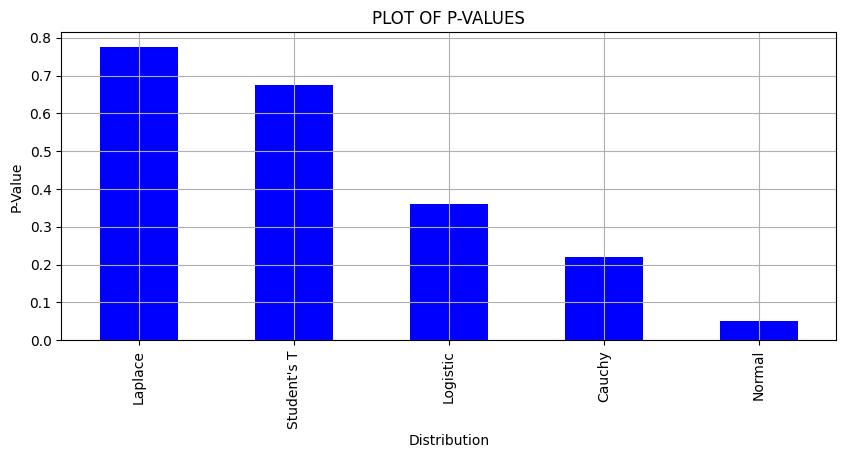

In [506]:
plt.figure(figsize=(10, 4))
pd.Series(df["p-value"].values,index=df["Distribution"]).plot(kind='bar',color='blue')
plt.title('PLOT OF P-VALUES')
plt.ylabel('P-Value')
plt.xlabel('Distribution')
plt.grid(True)
plt.show()

In [507]:
print("Best fit Distribution according to p_value is:",df["Distribution"].iloc[0],"Distribution")

Best fit Distribution according to p_value is: Laplace Distribution


Confidence Interval Analysis

In [508]:
confidence= 0.95
n= len(returns)
alpha= 1-confidence
mu= np.mean(returns)
s= np.std(returns)
critical_l = laplace.ppf(1-alpha/2)

ci_lower = mu - critical_l * (s/np.sqrt(n))
ci_upper = mu + critical_l * (s/np.sqrt(n))

outliers= returns[(returns < ci_lower)|(returns > ci_upper)]

Plotting the returns with outliers and Confidence Interval

In [509]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=returns.index,y=returns, name = "Daily Returns", line = dict(color='blue', width=1)))
fig.add_trace(go.Scatter(x=returns.index,y=[ci_upper]*len(returns), name = "95% CI Upper Bound", mode = 'lines', line= dict(color='red', dash='dash',width=3)))
fig.add_trace(go.Scatter(x=returns.index,y=[ci_lower]*len(returns), name = "95% CI Lower Bound", mode = 'lines', line = dict(color='green', dash='dash',width=3)))
fig.add_trace(go.Scatter(x=outliers.index,y=outliers,mode='markers',name='Outliers',marker=dict(color='black', size=5)))
fig.update_layout(title=dict(text="Daily Returns with 95% Confidence Interval (Logistic)",x=0.45,y=0.9,font=dict(size=30)),yaxis_title="Returns",xaxis_title="Indexed Date")
fig.show()

In [510]:
print("CI_Lower:",ci_lower)
print("CI_Upper:",ci_upper)
print("Outliers %:",outliers.count()/returns.count()*100)

CI_Lower: -0.0009503405401920404
CI_Upper: 0.004663889099209819
Outliers %: 75.91836734693878
